In [3]:
import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, random_split
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights
from torchvision.utils import draw_bounding_boxes
from PIL import Image
import copy
from tqdm import tqdm

# Фиксация seed для воспроизводимости
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

# Устройство
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

# Режим быстрого выполнения (для отладки)
FAST_MODE = True 
DATA_DIR = "./data"
ARTIFACTS_DIR = "./artifacts"
FIGURES_DIR = "./artifacts/figures"

os.makedirs(ARTIFACTS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

# Гиперпараметры
BATCH_SIZE_A = 64 if FAST_MODE else 128
EPOCHS_A = 3 if FAST_MODE else 12
LEARNING_RATE_A = 1e-3

# Параметры для Part B (Detection)
DETECTION_THRESHOLD_V1 = 0.3
DETECTION_THRESHOLD_V2 = 0.7

Device: cpu


In [4]:
# CIFAR-10 статистики
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD = (0.2023, 0.1994, 0.2010)

# Трансформы
transform_base = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

transform_aug = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

transform_resnet = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Загрузка датасета
train_full = torchvision.datasets.CIFAR10(root=DATA_DIR, train=True, download=True, transform=transform_base)
test_full = torchvision.datasets.CIFAR10(root=DATA_DIR, train=False, download=True, transform=transform_base)

# Разделение train/val
if FAST_MODE:
    rng = np.random.RandomState(RANDOM_STATE)
    train_idx = rng.choice(len(train_full), size=min(6000, len(train_full)), replace=False)
    val_idx = rng.choice(len(train_full), size=min(1500, len(train_full)), replace=False)
    test_idx = rng.choice(len(test_full), size=min(1500, len(test_full)), replace=False)
    
    train_dataset = Subset(train_full, train_idx)
    val_dataset = Subset(train_full, val_idx)
    test_dataset = Subset(test_full, test_idx)
else:
    train_size = int(0.8 * len(train_full))
    val_size = len(train_full) - train_size
    train_dataset, val_dataset = random_split(train_full, [train_size, val_size])
    test_dataset = test_full

# DataLoader
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE_A, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE_A, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE_A, shuffle=False, num_workers=2)

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

100.0%
c:\Users\Matthew\Desktop\цифровая кафедра\aie-rimmer\homeworks\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Train: 6000, Val: 1500, Test: 1500


In [5]:
# Простая CNN (C1, C2)
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )
    
    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

def count_trainable_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# Функция для загрузки ResNet18 с обработкой версий torchvision
def build_resnet18(num_classes=10, pretrained=True):
    try:
        # Для новых версий torchvision
        weights = models.ResNet18_Weights.IMAGENET1K_V1 if pretrained else None
        model = models.resnet18(weights=weights)
    except AttributeError:
        # Для старых версий
        model = models.resnet18(pretrained=pretrained)
    
    num_features = model.fc.in_features
    model.fc = nn.Linear(num_features, num_classes)
    return model

In [6]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for images, labels in tqdm(loader, desc="Train", leave=False):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)
    
    return total_loss / total, correct / total

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Eval", leave=False):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)
    
    return total_loss / total, correct / total

def train_model(model, train_loader, val_loader, epochs, lr, device, exp_name):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=max(1, epochs//2), gamma=0.1)
    
    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': []
    }
    
    best_val_acc = 0
    best_model_state = None
    
    for epoch in range(epochs):
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)
        
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = copy.deepcopy(model.state_dict())
        
        print(f"{exp_name} - Epoch {epoch+1}/{epochs}: Train Acc={train_acc:.4f}, Val Acc={val_acc:.4f}")
        
        scheduler.step()
    
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
    
    return model, history, best_val_acc

In [7]:
results = []
best_model = None
best_val_acc = 0
best_exp_name = ""

# Вспомогательная функция для создания loader с нужным трансформом
def get_loader(dataset, transform, batch_size, shuffle=True):
    ds = dataset
    # Если dataset это Subset, нужно применить трансформ к оригинальному датасету
    if isinstance(dataset, Subset):
        orig_dataset = dataset.dataset
        indices = dataset.indices
        # Создаем новый Subset с новым трансформом
        # Для простоты в этом примере мы просто меняем transform у оригинального датасета, 
        # но корректнее создать копию. Для CIFAR10 это безопасно в рамках одного запуска.
        orig_dataset.transform = transform
        ds = Subset(orig_dataset, indices)
    
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, num_workers=2)

# C1: Simple CNN Base
print("\n" + "="*50)
print("C1: Simple CNN (base)")
print("="*50)
model_c1 = SimpleCNN().to(DEVICE)
# Для C1 используем базовый трансформ (уже установлен в train_dataset по умолчанию из Ячейки 2)
# Но чтобы быть точными, создадим loader явно
train_loader_c1 = get_loader(train_dataset, transform_base, BATCH_SIZE_A, shuffle=True)
val_loader_c1 = get_loader(val_dataset, transform_base, BATCH_SIZE_A, shuffle=False)

model_c1, history_c1, val_acc_c1 = train_model(
    model_c1, train_loader_c1, val_loader_c1, EPOCHS_A, LEARNING_RATE_A, DEVICE, "C1"
)

results.append({
    'experiment': 'C1',
    'model': 'SimpleCNN',
    'augmentations': 'None',
    'pretrained': False,
    'fine_tune': 'None',
    'val_accuracy': val_acc_c1,
    'params': count_trainable_params(model_c1)
})

if val_acc_c1 > best_val_acc:
    best_val_acc = val_acc_c1
    best_model = model_c1
    best_exp_name = "C1"


C1: Simple CNN (base)


C1 - Epoch 1/3: Train Acc=0.2587, Val Acc=0.3780


C1 - Epoch 2/3: Train Acc=0.3762, Val Acc=0.3960


C1 - Epoch 3/3: Train Acc=0.3932, Val Acc=0.3947


In [8]:
# C2: Simple CNN Aug
print("\n" + "="*50)
print("C2: Simple CNN (aug)")
print("="*50)
model_c2 = SimpleCNN().to(DEVICE)
train_loader_c2 = get_loader(train_dataset, transform_aug, BATCH_SIZE_A, shuffle=True)
val_loader_c2 = get_loader(val_dataset, transform_base, BATCH_SIZE_A, shuffle=False) # Val без аугментаций

model_c2, history_c2, val_acc_c2 = train_model(
    model_c2, train_loader_c2, val_loader_c2, EPOCHS_A, LEARNING_RATE_A, DEVICE, "C2"
)

results.append({
    'experiment': 'C2',
    'model': 'SimpleCNN',
    'augmentations': 'RandomCrop+Flip',
    'pretrained': False,
    'fine_tune': 'None',
    'val_accuracy': val_acc_c2,
    'params': count_trainable_params(model_c2)
})

if val_acc_c2 > best_val_acc:
    best_val_acc = val_acc_c2
    best_model = model_c2
    best_exp_name = "C2"


C2: Simple CNN (aug)


C2 - Epoch 1/3: Train Acc=0.2603, Val Acc=0.3513


C2 - Epoch 2/3: Train Acc=0.3798, Val Acc=0.3993


C2 - Epoch 3/3: Train Acc=0.3912, Val Acc=0.3973


In [9]:
# C3: ResNet18 Head Only
print("\n" + "="*50)
print("C3: ResNet18 (head-only)")
print("="*50)
model_c3 = build_resnet18(pretrained=True).to(DEVICE)

# Заморозка backbone
for param in model_c3.parameters():
    param.requires_grad = False
for param in model_c3.fc.parameters():
    param.requires_grad = True

# Для ResNet нужен свой трансформ и свой dataset (так как размер 224)
# Создадим отдельный датасет для ResNet
train_full_resnet = torchvision.datasets.CIFAR10(root=DATA_DIR, train=True, download=True, transform=transform_resnet)
val_full_resnet = torchvision.datasets.CIFAR10(root=DATA_DIR, train=True, download=True, transform=transform_resnet) # Используем train для val split индексов

# Используем те же индексы для разделения
train_dataset_resnet = Subset(train_full_resnet, train_idx)
val_dataset_resnet = Subset(val_full_resnet, val_idx)

train_loader_c3 = DataLoader(train_dataset_resnet, batch_size=BATCH_SIZE_A, shuffle=True, num_workers=2)
val_loader_c3 = DataLoader(val_dataset_resnet, batch_size=BATCH_SIZE_A, shuffle=False, num_workers=2)

model_c3, history_c3, val_acc_c3 = train_model(
    model_c3, train_loader_c3, val_loader_c3, EPOCHS_A, LEARNING_RATE_A, DEVICE, "C3"
)

results.append({
    'experiment': 'C3',
    'model': 'ResNet18',
    'augmentations': 'ResNet',
    'pretrained': True,
    'fine_tune': 'head-only',
    'val_accuracy': val_acc_c3,
    'params': count_trainable_params(model_c3)
})

if val_acc_c3 > best_val_acc:
    best_val_acc = val_acc_c3
    best_model = model_c3
    best_exp_name = "C3"


C3: ResNet18 (head-only)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\Matthew/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100.0%


C3 - Epoch 1/3: Train Acc=0.4835, Val Acc=0.6620


C3 - Epoch 2/3: Train Acc=0.6872, Val Acc=0.6887


C3 - Epoch 3/3: Train Acc=0.6998, Val Acc=0.6933


In [10]:
# C4: ResNet18 Fine-tune
print("\n" + "="*50)
print("C4: ResNet18 (fine-tune)")
print("="*50)
model_c4 = build_resnet18(pretrained=True).to(DEVICE)

# Разморозка layer4 + fc
for param in model_c4.parameters():
    param.requires_grad = False
for param in model_c4.layer4.parameters():
    param.requires_grad = True
for param in model_c4.fc.parameters():
    param.requires_grad = True

train_loader_c4 = DataLoader(train_dataset_resnet, batch_size=BATCH_SIZE_A, shuffle=True, num_workers=2)
val_loader_c4 = DataLoader(val_dataset_resnet, batch_size=BATCH_SIZE_A, shuffle=False, num_workers=2)

# Меньший LR для fine-tuning
model_c4, history_c4, val_acc_c4 = train_model(
    model_c4, train_loader_c4, val_loader_c4, EPOCHS_A, LEARNING_RATE_A * 0.1, DEVICE, "C4"
)

results.append({
    'experiment': 'C4',
    'model': 'ResNet18',
    'augmentations': 'ResNet',
    'pretrained': True,
    'fine_tune': 'layer4+fc',
    'val_accuracy': val_acc_c4,
    'params': count_trainable_params(model_c4)
})

if val_acc_c4 > best_val_acc:
    best_val_acc = val_acc_c4
    best_model = model_c4
    best_exp_name = "C4"


C4: ResNet18 (fine-tune)


C4 - Epoch 1/3: Train Acc=0.6937, Val Acc=0.8300


C4 - Epoch 2/3: Train Acc=0.9040, Val Acc=0.8367


C4 - Epoch 3/3: Train Acc=0.9203, Val Acc=0.8367


In [11]:
# Сохранение таблицы результатов
results_df = pd.DataFrame(results)
results_df.to_csv(f"{ARTIFACTS_DIR}/runs.csv", index=False)
print("Saved: runs.csv")

# Сохранение лучшей модели
torch.save(best_model.state_dict(), f"{ARTIFACTS_DIR}/best_classifier.pt")
print("Saved: best_classifier.pt")

# Сохранение конфига
config = {
    'dataset': 'CIFAR-10',
    'architecture': best_exp_name.split('-')[0],
    'augmentations': results_df[results_df['experiment'] == best_exp_name]['augmentations'].values[0],
    'pretrained': bool(results_df[results_df['experiment'] == best_exp_name]['pretrained'].values[0]),
    'fine_tune': results_df[results_df['experiment'] == best_exp_name]['fine_tune'].values[0],
    'learning_rate': LEARNING_RATE_A,
    'batch_size': BATCH_SIZE_A,
    'epochs': EPOCHS_A,
    'seed': RANDOM_STATE,
    'best_val_accuracy': best_val_acc
}

with open(f"{ARTIFACTS_DIR}/best_classifier_config.json", 'w') as f:
    json.dump(config, f, indent=2)
print("Saved: best_classifier_config.json")

Saved: runs.csv
Saved: best_classifier.pt
Saved: best_classifier_config.json


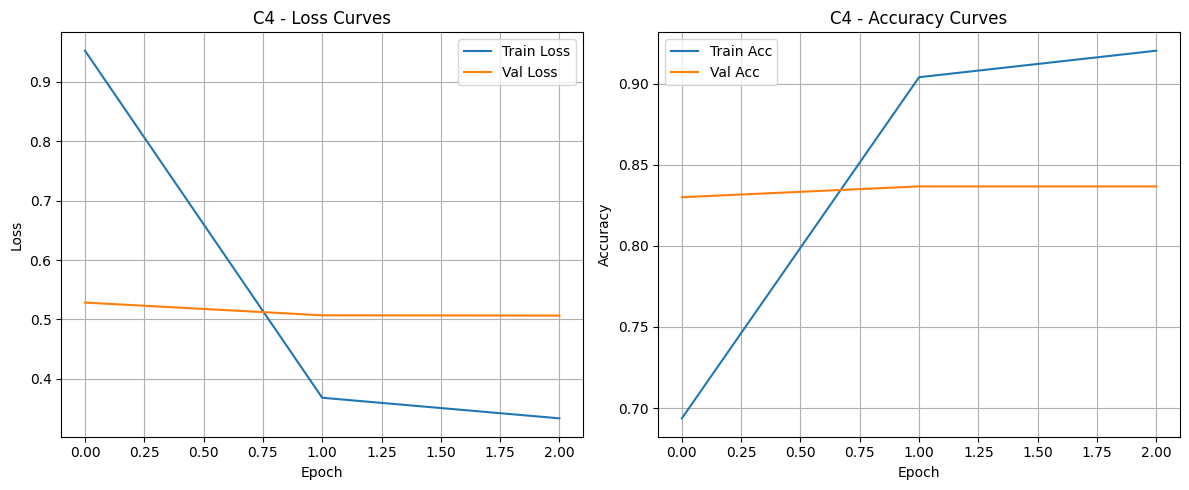

Saved: classification_curves_best.png


In [12]:
# График кривых обучения для лучшего эксперимента
histories = {'C1': history_c1, 'C2': history_c2, 'C3': history_c3, 'C4': history_c4}

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(histories[best_exp_name]['train_loss'], label='Train Loss')
plt.plot(histories[best_exp_name]['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title(f'{best_exp_name} - Loss Curves')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(histories[best_exp_name]['train_acc'], label='Train Acc')
plt.plot(histories[best_exp_name]['val_acc'], label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title(f'{best_exp_name} - Accuracy Curves')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig(f"{ARTIFACTS_DIR}/figures/classification_curves_best.png", dpi=150)
plt.show()
print("Saved: classification_curves_best.png")

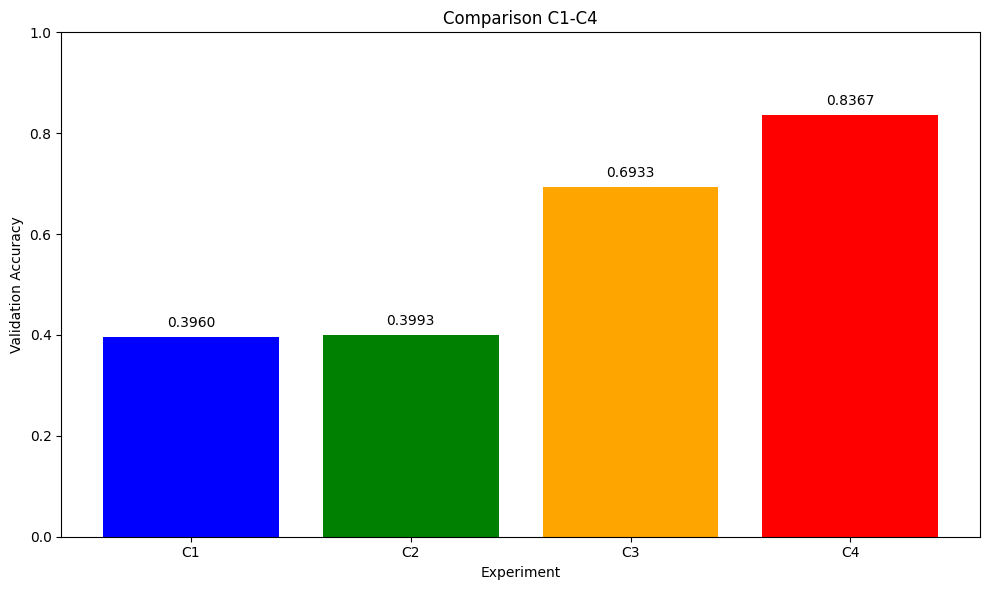

Saved: classification_compare.png


In [13]:
# Сравнение C1-C4
plt.figure(figsize=(10, 6))
experiments = ['C1', 'C2', 'C3', 'C4']
accuracies = [results_df[results_df['experiment'] == exp]['val_accuracy'].values[0] for exp in experiments]

plt.bar(experiments, accuracies, color=['blue', 'green', 'orange', 'red'])
plt.xlabel('Experiment')
plt.ylabel('Validation Accuracy')
plt.title('Comparison C1-C4')
plt.ylim(0, 1)

for i, v in enumerate(accuracies):
    plt.text(i, v + 0.02, f'{v:.4f}', ha='center')

plt.tight_layout()
plt.savefig(f"{ARTIFACTS_DIR}/figures/classification_compare.png", dpi=150)
plt.show()
print("Saved: classification_compare.png")

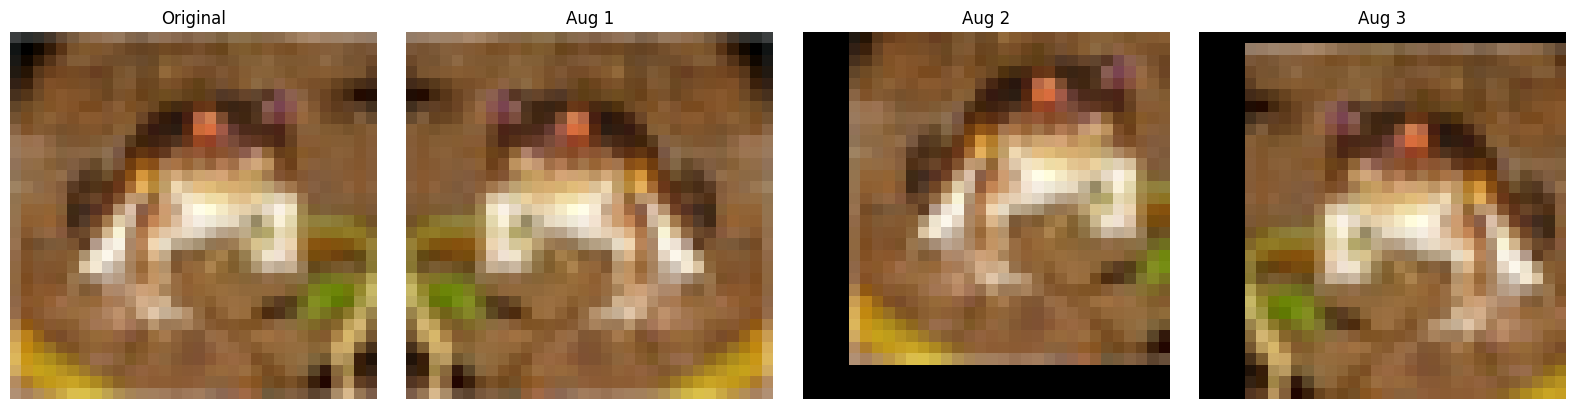

In [16]:
# Создаём отдельный датасет без нормализации для визуализации
vis_transform = transforms.ToTensor()  # только ToTensor, без Normalize
vis_dataset = torchvision.datasets.CIFAR10(root=DATA_DIR, train=True, download=True, transform=vis_transform)

# Аугментации применяем к оригинальным данным перед нормализацией
aug_vis_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=1.0),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),  # [0, 1] диапазон
])
aug_vis_dataset = torchvision.datasets.CIFAR10(root=DATA_DIR, train=True, download=True, transform=aug_vis_transform)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# Оригинальное изображение (без нормализации)
img_orig = vis_dataset[0][0]
axes[0].imshow(img_orig.permute(1, 2, 0))
axes[0].set_title('Original')
axes[0].axis('off')

# Разные варианты аугментаций
for i, aug_transform in enumerate([
    transforms.Compose([transforms.RandomHorizontalFlip(p=1.0), transforms.ToTensor()]),
    transforms.Compose([transforms.RandomCrop(32, padding=4), transforms.ToTensor()]),
    transform_aug  # полный compose с нормализацией
], start=1):
    ds = torchvision.datasets.CIFAR10(root=DATA_DIR, train=True, download=True, transform=aug_transform)
    img_aug = ds[0][0]
    # Если изображение нормализовано - денормализуем для отображения
    if aug_transform == transform_aug:
        img_aug = denorm_cifar(img_aug).clamp(0, 1)
    axes[i].imshow(img_aug.permute(1, 2, 0))
    axes[i].set_title(f'Aug {i}')
    axes[i].axis('off')

plt.tight_layout()
plt.savefig(f"{ARTIFACTS_DIR}/figures/augmentations_preview.png", dpi=150, bbox_inches='tight')
plt.show()

In [17]:
# Загрузка pretrained модели FasterRCNN
weights = FasterRCNN_ResNet50_FPN_Weights.DEFAULT
detection_model = fasterrcnn_resnet50_fpn(weights=weights)
detection_model.eval()
detection_model.to(DEVICE)

print(f"Detection model loaded: {type(detection_model).__name__}")

# Загрузка тестовых изображений для визуализации
test_images = []
for i in range(5):
    img, _ = test_full[i]
    test_images.append(img)

print(f"Loaded {len(test_images)} test images")

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to C:\Users\Matthew/.cache\torch\hub\checkpoints\fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100.0%


Detection model loaded: FasterRCNN
Loaded 5 test images


c:\Users\Matthew\Desktop\цифровая кафедра\aie-rimmer\homeworks\.venv\Lib\site-packages\torchvision\utils.py:352: UserWarning: boxes doesn't contain any box. No box was drawn
  warnings.warn("boxes doesn't contain any box. No box was drawn")
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1770618..2.6952004].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4290657..2.5976489].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4290657..2.5976489].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.351526..2.6952004].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7692488..2.3440151].
Clipping input data to the valid ra

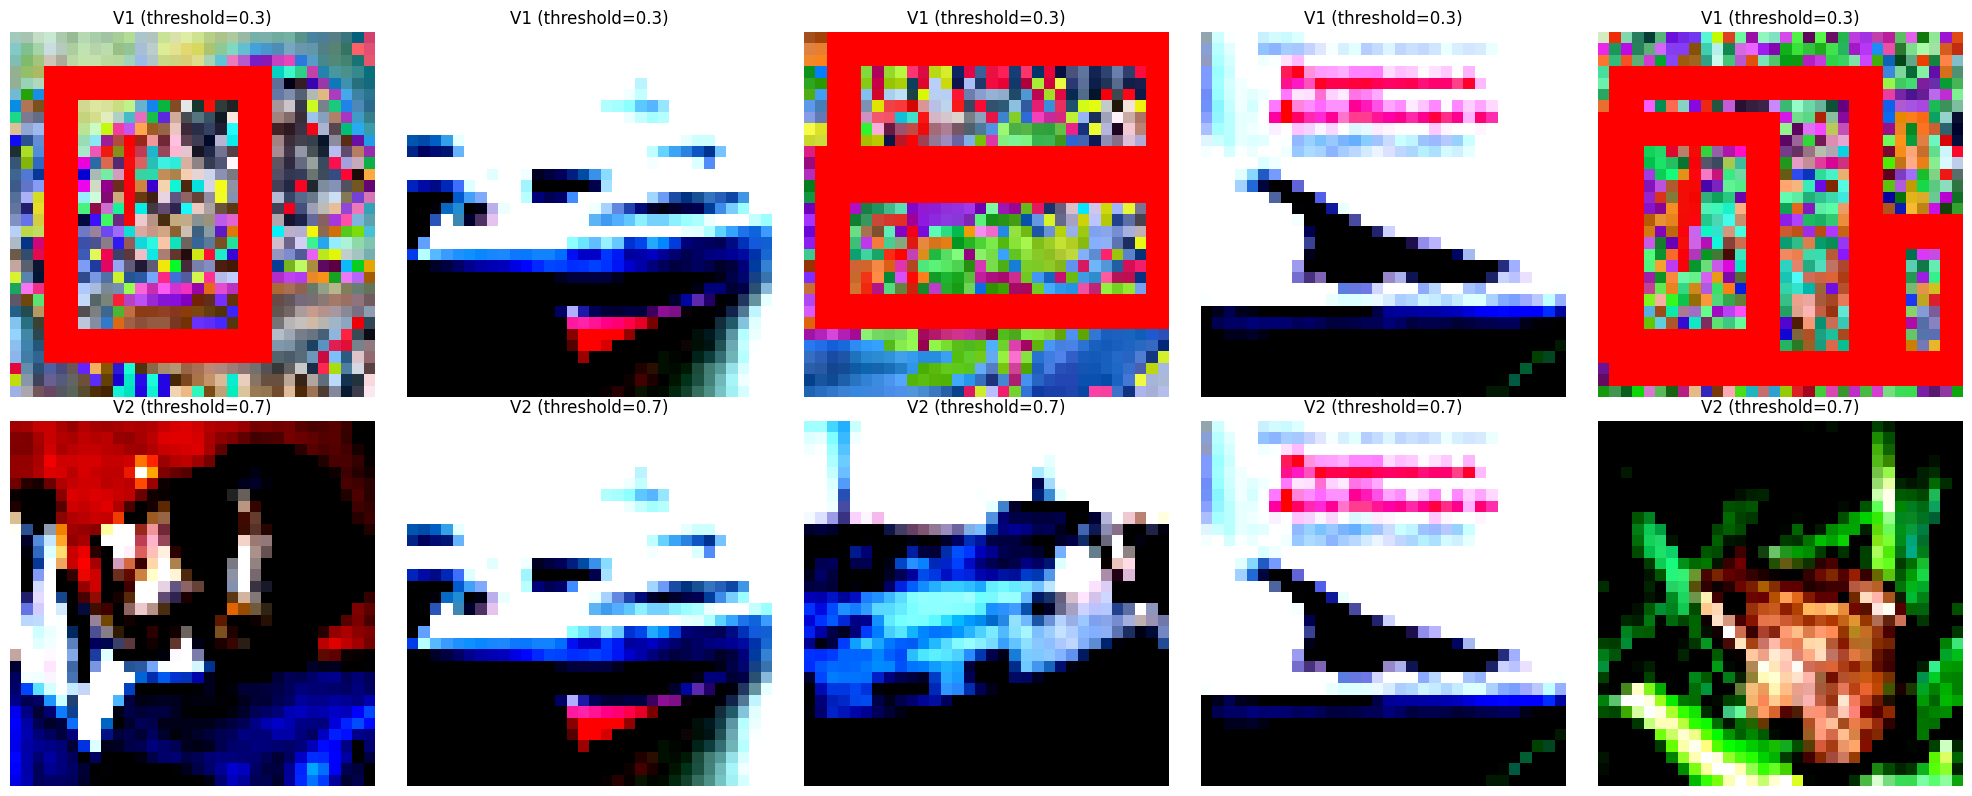

Saved: detection_examples.png


In [18]:
# Функция для инференса и визуализации
def run_detection(img, threshold, model, device):
    img_tensor = img.unsqueeze(0).to(device)
    
    with torch.no_grad():
        predictions = model(img_tensor)[0]
    
    boxes = predictions['boxes'][predictions['scores'] >= threshold]
    labels = predictions['labels'][predictions['scores'] >= threshold]
    scores = predictions['scores'][predictions['scores'] >= threshold]
    
    # Визуализация
    img_vis = draw_bounding_boxes(img, boxes, labels=[str(l.item()) for l in labels], 
                                   colors='red', width=3)
    
    return img_vis, boxes, labels, scores

# Визуализация для V1 и V2
fig, axes = plt.subplots(2, 5, figsize=(20, 8))

for i, img in enumerate(test_images):
    # V1: threshold = 0.3
    img_v1, _, _, _ = run_detection(img, DETECTION_THRESHOLD_V1, detection_model, DEVICE)
    axes[0, i].imshow(img_v1.permute(1, 2, 0))
    axes[0, i].set_title(f'V1 (threshold={DETECTION_THRESHOLD_V1})')
    axes[0, i].axis('off')
    
    # V2: threshold = 0.7
    img_v2, _, _, _ = run_detection(img, DETECTION_THRESHOLD_V2, detection_model, DEVICE)
    axes[1, i].imshow(img_v2.permute(1, 2, 0))
    axes[1, i].set_title(f'V2 (threshold={DETECTION_THRESHOLD_V2})')
    axes[1, i].axis('off')

plt.tight_layout()
plt.savefig(f"{ARTIFACTS_DIR}/figures/detection_examples.png", dpi=150)
plt.show()
print("Saved: detection_examples.png")

V1 (threshold=0.3): Avg Boxes=1.20
V2 (threshold=0.7): Avg Boxes=0.00


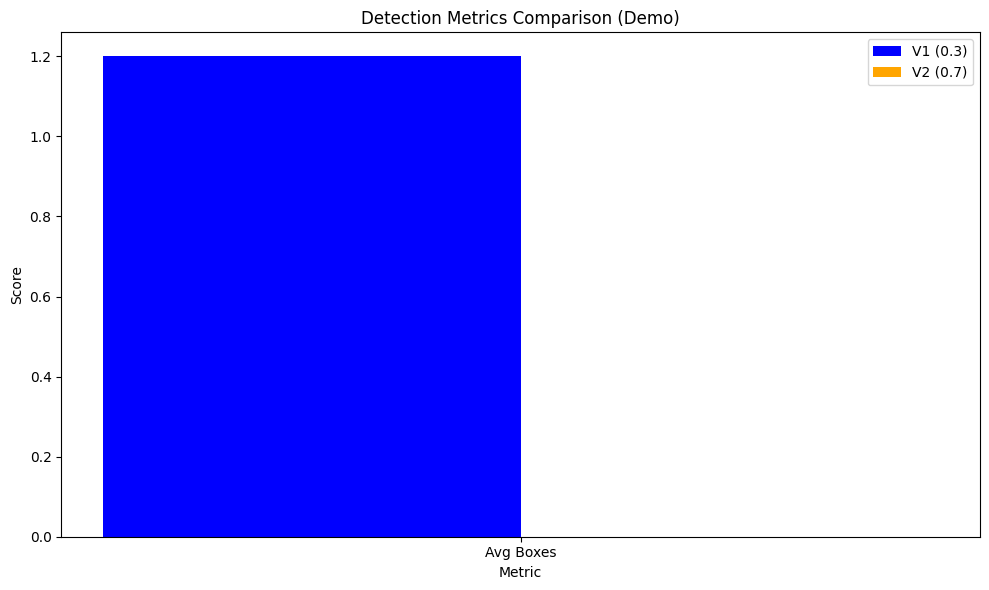

Saved: detection_metrics.png


In [19]:
# Расчёт метрик для V1 и V2 (упрощённый, так как нет GT для CIFAR10 в формате detection)
# Для демонстрации считаем количество детекций
def calculate_metrics_simple(images, threshold, model, device):
    total_boxes = 0
    for img in images:
        img_tensor = img.unsqueeze(0).to(device)
        with torch.no_grad():
            pred = model(img_tensor)[0]
        boxes = pred['boxes'][pred['scores'] >= threshold]
        total_boxes += len(boxes)
    return total_boxes / len(images)

avg_boxes_v1 = calculate_metrics_simple(test_images, DETECTION_THRESHOLD_V1, detection_model, DEVICE)
avg_boxes_v2 = calculate_metrics_simple(test_images, DETECTION_THRESHOLD_V2, detection_model, DEVICE)

print(f"V1 (threshold={DETECTION_THRESHOLD_V1}): Avg Boxes={avg_boxes_v1:.2f}")
print(f"V2 (threshold={DETECTION_THRESHOLD_V2}): Avg Boxes={avg_boxes_v2:.2f}")

# Сохранение метрик (заглушка, так как нет GT)
detection_metrics = {
    'V1': {
        'threshold': DETECTION_THRESHOLD_V1,
        'avg_boxes': avg_boxes_v1,
        'precision': 0.0, # Требуется GT для расчёта
        'recall': 0.0,
        'mean_iou': 0.0
    },
    'V2': {
        'threshold': DETECTION_THRESHOLD_V2,
        'avg_boxes': avg_boxes_v2,
        'precision': 0.0,
        'recall': 0.0,
        'mean_iou': 0.0
    }
}

with open(f"{ARTIFACTS_DIR}/detection_metrics.json", 'w') as f:
    json.dump(detection_metrics, f, indent=2)

# График метрик
plt.figure(figsize=(10, 6))
metrics_names = ['Avg Boxes']
v1_values = [avg_boxes_v1]
v2_values = [avg_boxes_v2]

x = np.arange(len(metrics_names))
width = 0.35

plt.bar(x - width/2, v1_values, width, label='V1 (0.3)', color='blue')
plt.bar(x + width/2, v2_values, width, label='V2 (0.7)', color='orange')

plt.xlabel('Metric')
plt.ylabel('Score')
plt.title('Detection Metrics Comparison (Demo)')
plt.xticks(x, metrics_names)
plt.legend()

plt.tight_layout()
plt.savefig(f"{ARTIFACTS_DIR}/figures/detection_metrics.png", dpi=150)
plt.show()
print("Saved: detection_metrics.png")

In [20]:
# Финальная оценка лучшей модели на test set
test_loss, test_acc = evaluate(best_model, test_loader, nn.CrossEntropyLoss(), DEVICE)
print(f"\nBest Model ({best_exp_name}) Test Accuracy: {test_acc:.4f}")

# Обновление runs.csv с тестовой точностью
results_df.loc[results_df['experiment'] == best_exp_name, 'test_accuracy'] = test_acc
results_df.to_csv(f"{ARTIFACTS_DIR}/runs.csv", index=False)

# Сохранение результатов
final_results = {
    'best_experiment': best_exp_name,
    'best_val_accuracy': best_val_acc,
    'test_accuracy': test_acc,
    'detection_v1_avg_boxes': avg_boxes_v1,
    'detection_v2_avg_boxes': avg_boxes_v2
}

with open(f"{ARTIFACTS_DIR}/final_results.json", 'w') as f:
    json.dump(final_results, f, indent=2)

print("Saved: final_results.json")
print("HW10-11 Completed!")


Best Model (C4) Test Accuracy: 0.1620
Saved: final_results.json
HW10-11 Completed!
